Examining class imbalance in the UiS4ADL and PAAL ADL datasets after segmentation into 4-second windows, with shorter recordings retained.

In [ ]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import warnings
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Add parent directory to sys.path to access local modules
sys.path.append('..')

# Suppress warnings
warnings.filterwarnings('ignore')

In [ ]:
UIS_100HZ_PATH = r"../Data/UiS4ADL/Processed/UiS4ADL_100hz.csv"
PAAL_32HZ_PATH = r"../Data/PAAL_ADL/Processed/PAAL_ADL_32hz.csv"

WINDOW_SECONDS = 4.0
UIS_FS = 100
PAAL_FS = 32

In [ ]:
def count_windows_detailed(path, fs, dataset_name):
    """
    Count segments per activity by separating:
    - recordings >= 4s into standard non-overlapping 4s windows
    - recordings < 4s into one retained short segment
    """
    print(f"Processing window counts for: {dataset_name}...")
    df = pd.read_csv(path)

    long_counts = {i: 0 for i in range(1, 25)}
    short_counts = {i: 0 for i in range(1, 25)}

    window_samples = int(WINDOW_SECONDS * fs)

    for _, group in df.groupby('fileID'):
        label = int(group['adl'].iloc[0])
        duration_samples = len(group)

        if duration_samples >= window_samples:
            num_windows = duration_samples // window_samples
            long_counts[label] += num_windows
        else:
            short_counts[label] += 1

    return pd.DataFrame({
        'long_segments': pd.Series(long_counts),
        'short_segments': pd.Series(short_counts)
    }).sort_index()


uis_counts_df = count_windows_detailed(UIS_100HZ_PATH, fs=UIS_FS, dataset_name="UiS4ADL")
paal_counts_df = count_windows_detailed(PAAL_32HZ_PATH, fs=PAAL_FS, dataset_name="PAAL ADL")


Processing window counts for: UiS4ADL...
Processing window counts for: PAAL ADL...


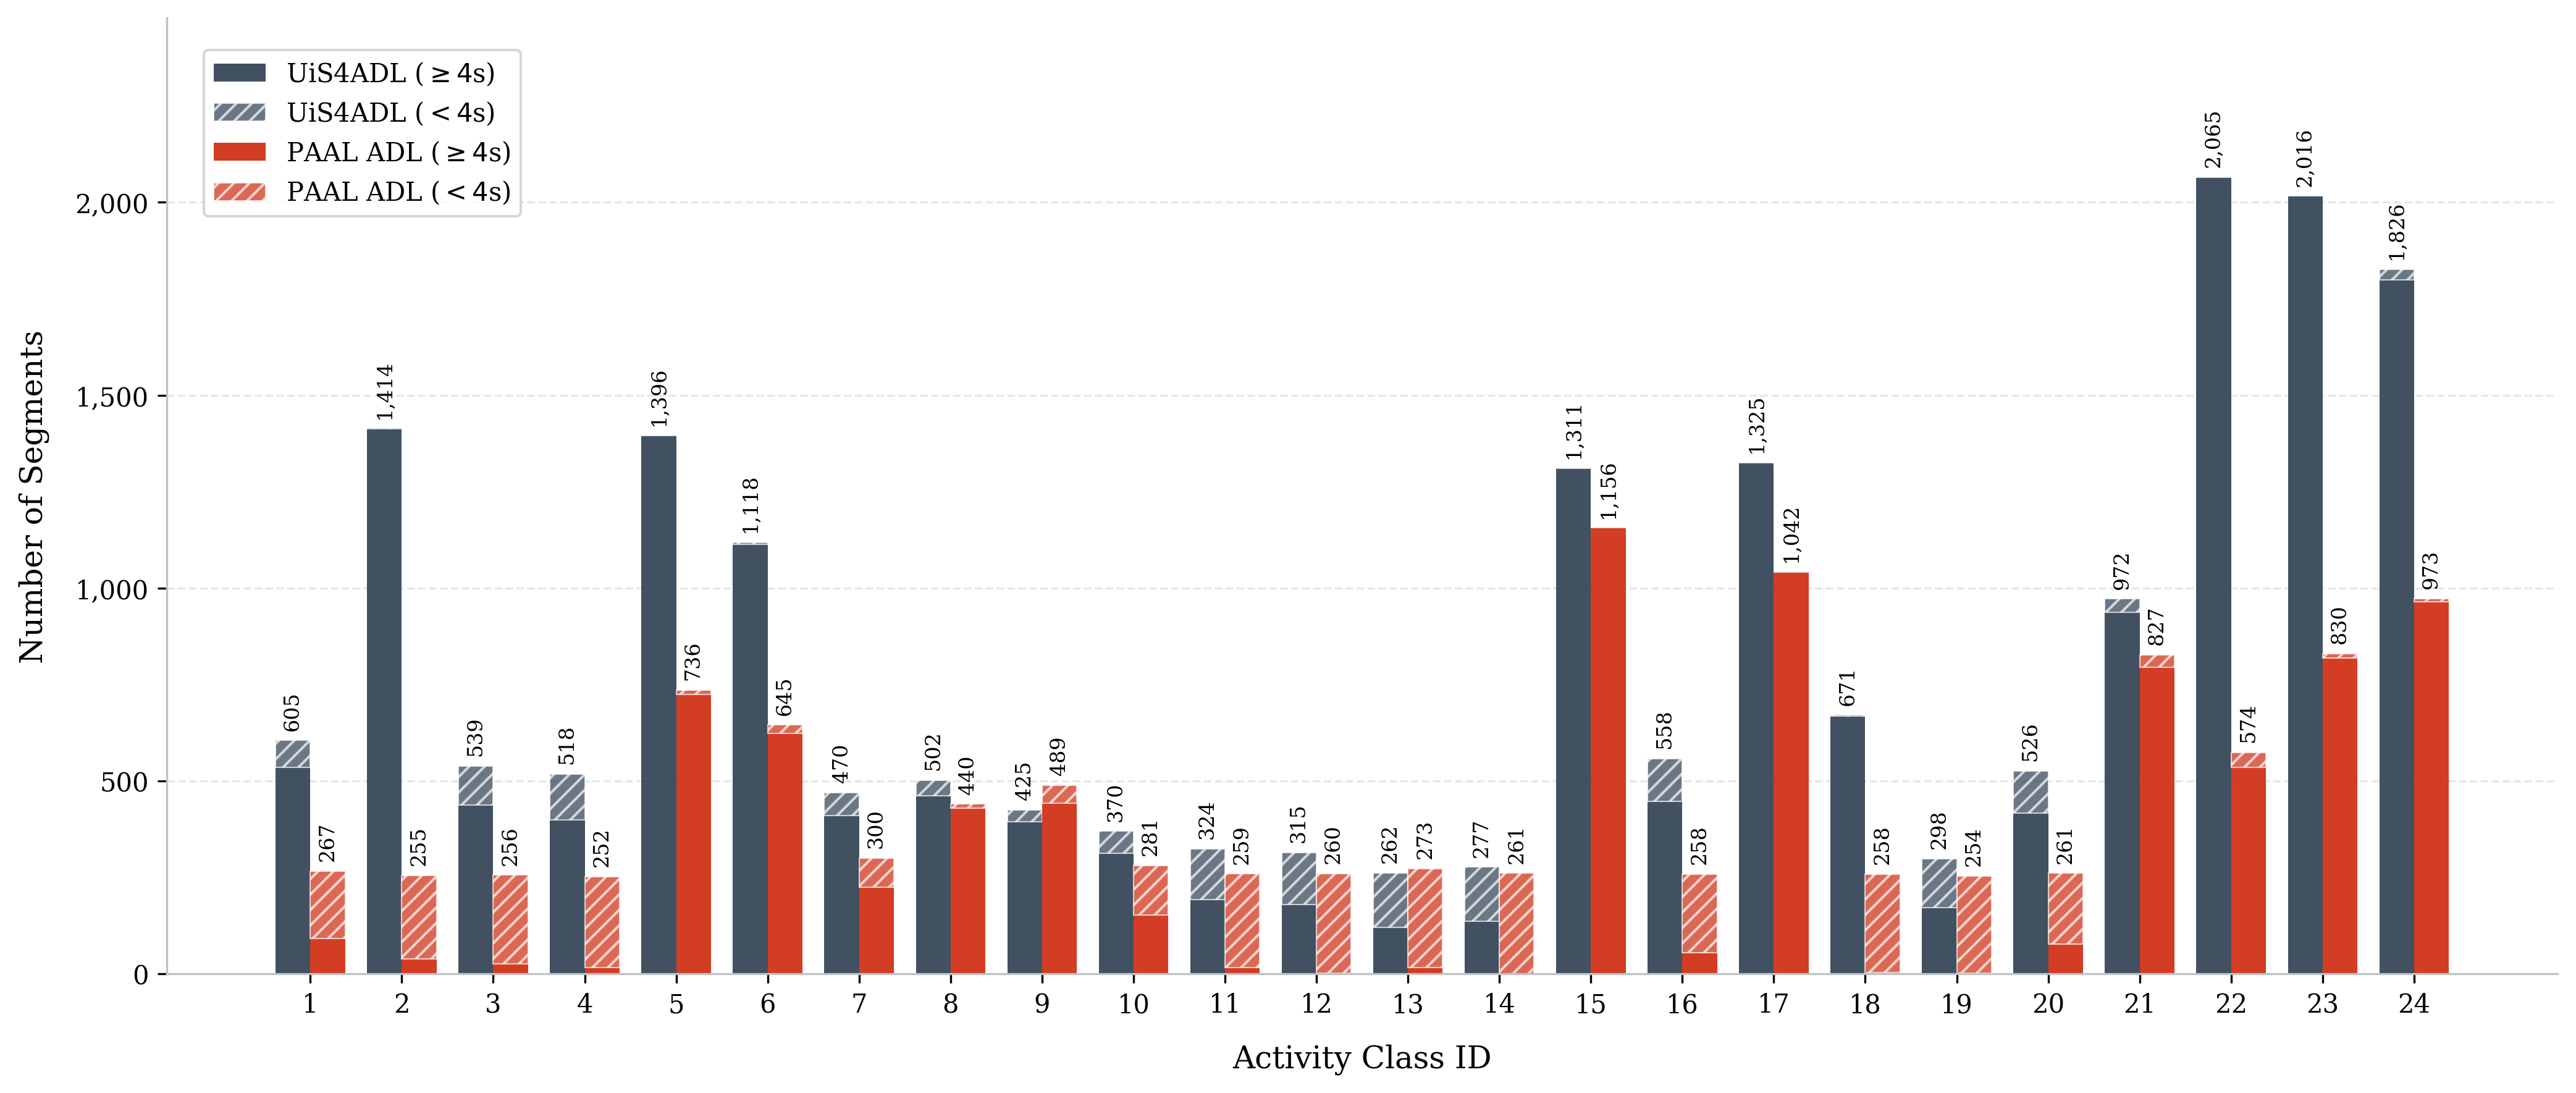

In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 0.8

x = np.arange(1, 25)
width = 0.38

fig, ax = plt.subplots(figsize=(14, 6), dpi=300)

color_uis = '#2c3e50'
color_paal = '#cd280b'

# UiS4ADL: long + short stacked
bars_uis_long = ax.bar(
    x - width/2,
    uis_counts_df['long_segments'].values,
    width,
    label='UiS4ADL ($\\geq 4$s)',
    color=color_uis,
    alpha=0.9
)

bars_uis_short = ax.bar(
    x - width/2,
    uis_counts_df['short_segments'].values,
    width,
    bottom=uis_counts_df['long_segments'].values,
    label='UiS4ADL ($< 4$s)',
    color=color_uis,
    alpha=0.7,
    hatch='////',
    edgecolor='white',
    linewidth=0.5
)

# PAAL ADL: long + short stacked
bars_paal_long = ax.bar(
    x + width/2,
    paal_counts_df['long_segments'].values,
    width,
    label='PAAL ADL ($\\geq 4$s)',
    color=color_paal,
    alpha=0.9
)

bars_paal_short = ax.bar(
    x + width/2,
    paal_counts_df['short_segments'].values,
    width,
    bottom=paal_counts_df['long_segments'].values,
    label='PAAL ADL ($< 4$s)',
    color=color_paal,
    alpha=0.7,
    hatch='////',
    edgecolor='white',
    linewidth=0.5
)

ax.set_xlabel('Activity Class ID', fontsize=12, labelpad=10)
ax.set_ylabel('Number of Segments', fontsize=12, labelpad=10)
ax.set_xticks(x)
ax.set_xticklabels(x, fontsize=10)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}"))

uis_totals = uis_counts_df['long_segments'] + uis_counts_df['short_segments']
paal_totals = paal_counts_df['long_segments'] + paal_counts_df['short_segments']

for i, val in enumerate(x):
    uis_total = uis_totals.iloc[i]
    if uis_total > 0:
        ax.annotate(
            f"{int(uis_total):,}",
            xy=(val - width/2, uis_total),
            xytext=(0, 4),
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=8,
            rotation=90
        )

    paal_total = paal_totals.iloc[i]
    if paal_total > 0:
        ax.annotate(
            f"{int(paal_total):,}",
            xy=(val + width/2, paal_total),
            xytext=(0, 4),
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=8,
            rotation=90
        )

ax.legend(frameon=True, loc='upper left', bbox_to_anchor=(0.01, 0.98), fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#bdc3c7')
ax.spines['bottom'].set_color('#bdc3c7')
ax.grid(axis='y', linestyle='--', alpha=0.4, color='#bdc3c7')
ax.set_axisbelow(True)

max_height = max(uis_totals.max(), paal_totals.max())
ax.set_ylim(0, max_height * 1.2)

plt.tight_layout()
plt.savefig(f"../Results/Figures/Figure_4_3_1_class_imbalance_new.pdf", bbox_inches='tight')
plt.show()